# FIT5149 Week 9: Undirected Graphical Models

This notebook has two sections:

| Section | What you do | Library |
|---|---|---|
| I. Markov networks | Build a small Markov network, read its independencies, answer probability and MAP queries | `pgmpy` |
| II. Conditional random fields | Train a per-token tagger and a linear-chain CRF on the same emission scores, compare them, read the transition matrix | `torch`, `pytorch-crf` |

Both sections contain activities. Section III, *From a model to an application*, is a separate demonstration notebook (`Week_9_Section_III_From_Model_to_App.ipynb`) that starts from this one and prepares you for Part III of Assessment 2.

**Setup.** Run the cell below once if a library is missing. Versions are pinned so that the code behaves the same on every machine.

In [1]:
# Uncomment and run once. pgmpy 1.x renamed several classes (MarkovNetwork -> DiscreteMarkovNetwork),
# so older tutorials on the web will not run against the version pinned here.
# !pip install pgmpy==1.1.2 networkx matplotlib pandas scikit-learn
# !pip install torch pytorch-crf==0.7.2

## I. Design of Markov Networks

#### Goals
* Understand how to build a Markov network using `pgmpy`.
* Explore the basic properties of Markov networks.
* Answer simple probability and MAP queries on a Markov network.

### Scenario

Four students get together in pairs to work on the homework for a class. For various reasons, only the following pairs meet: Alice and Bob; Bob and Charles; Charles and Debbie; and Debbie and Alice. (Alice and Charles just can't stand each other, and Bob and Debbie had a relationship that ended badly.)
The professor made a mistake in class. Any of the four students may figure out the problem and transmit this understanding to his or her study partners. We need to determine whether a student has the misconception or not.

Each student is a binary random variable (0 = no misconception, 1 = misconception). Each pair that studies together is an undirected edge, and each edge carries a **factor**: a table of four non-negative numbers saying how compatible each combination of the two students' values is. A factor is *not* a probability table; it is only normalised when all factors are multiplied together and divided by the partition function $Z$.

In [2]:
import os, warnings
os.environ["TQDM_DISABLE"] = "1"                                  # pgmpy shows progress bars for tiny computations; turn them off
warnings.filterwarnings("ignore", category=FutureWarning)         # pgmpy prints deprecation notices for classes we do not use
warnings.filterwarnings("ignore", message="IProgress not found")  # progress-bar widget notice from tqdm

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# pgmpy 1.x: the class is DiscreteMarkovNetwork (the old name MarkovNetwork now raises an ImportError).
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation, VariableElimination
from pgmpy.sampling import GibbsSampling

np.random.seed(0)   # fixed seed so the random factor values, and therefore the query answers, are reproducible

In [3]:
# 1. The graph: one node per student, one undirected edge per pair that studies together.
mn_student = DiscreteMarkovNetwork()
mn_student.add_edges_from([('Alice', 'Bob'), ('Alice', 'Debbie'), ('Bob', 'Charles'), ('Debbie', 'Charles')])

# 2. One factor per edge. cardinality=[2, 2] means both variables are binary; the four values
#    are the compatibilities of (0,0), (0,1), (1,0), (1,1). We draw them at random for the exercise.
factor_ab = DiscreteFactor(['Alice', 'Bob'],     cardinality=[2, 2], values=np.random.rand(4))
factor_ad = DiscreteFactor(['Alice', 'Debbie'],  cardinality=[2, 2], values=np.random.rand(4))
factor_bc = DiscreteFactor(['Bob', 'Charles'],   cardinality=[2, 2], values=np.random.rand(4))
factor_dc = DiscreteFactor(['Debbie', 'Charles'], cardinality=[2, 2], values=np.random.rand(4))

# 3. Attach the factors to the graph. The joint distribution is their product divided by Z.
mn_student.add_factors(factor_ab, factor_ad, factor_bc, factor_dc)

### Factors in a Markov network

In [4]:
for factor in mn_student.get_factors():
    print(factor)   # each row: an assignment to the two variables and its (unnormalised) compatibility

+----------+--------+------------------+
| Alice    | Bob    |   phi(Alice,Bob) |
+==========+========+==================+
| Alice(0) | Bob(0) |           0.5488 |
+----------+--------+------------------+
| Alice(0) | Bob(1) |           0.7152 |
+----------+--------+------------------+
| Alice(1) | Bob(0) |           0.6028 |
+----------+--------+------------------+
| Alice(1) | Bob(1) |           0.5449 |
+----------+--------+------------------+
+----------+-----------+---------------------+
| Alice    | Debbie    |   phi(Alice,Debbie) |
+==========+===========+=====================+
| Alice(0) | Debbie(0) |              0.4237 |
+----------+-----------+---------------------+
| Alice(0) | Debbie(1) |              0.6459 |
+----------+-----------+---------------------+
| Alice(1) | Debbie(0) |              0.4376 |
+----------+-----------+---------------------+
| Alice(1) | Debbie(1) |              0.8918 |
+----------+-----------+---------------------+
+--------+------------+---------

### Visualising Markov networks

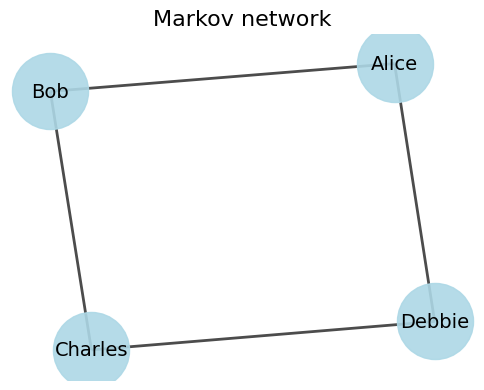

In [5]:
def visualise(undirected_graph):
    # Convert the pgmpy model to a plain networkx graph and draw it.
    g = nx.Graph()
    g.add_nodes_from(undirected_graph.nodes())
    g.add_edges_from(undirected_graph.edges())
    plt.figure(figsize=(6, 4.5))
    pos = nx.spring_layout(g, seed=1)      # node positions; the seed keeps the layout stable
    nx.draw_networkx_nodes(g, pos, node_color='lightblue', node_size=3000, alpha=0.9)
    nx.draw_networkx_edges(g, pos, width=2, alpha=0.7)
    nx.draw_networkx_labels(g, pos, font_size=14)
    plt.title("Markov network", fontsize=16)
    plt.axis('off')
    plt.show()

visualise(mn_student)

### Independencies in Markov networks

In an undirected graph, two variables are conditionally independent given a set $S$ if every path between them passes through $S$. `get_local_independencies()` lists, for every node, that it is independent of the non-neighbours given its neighbours (the local Markov property from the lecture).

In [6]:
mn_student.get_local_independencies()

(Alice ⟂ Charles | Bob, Debbie)
(Bob ⟂ Debbie | Alice, Charles)
(Debbie ⟂ Bob | Alice, Charles)
(Charles ⟂ Alice | Bob, Debbie)

### Inference

We answer probability queries and MAP queries with [belief propagation on a junction tree](https://ermongroup.github.io/cs228-notes/inference/jt/). Understanding this algorithm is optional this week (Week 10 covers exact inference); here we only need to know how to call it. Below we compute $P(\text{Alice})$, $P(\text{Alice} \mid \text{Bob}=1)$, draw a few samples, and find the most likely value of Alice given $\text{Bob}=1$.

In [7]:
belief_inf = BeliefPropagation(mn_student)   # exact inference engine (Week 10)
print(belief_inf.query(['Alice']))           # marginal P(Alice): sum out Bob, Charles, Debbie, then normalise

+----------+--------------+
| Alice    |   phi(Alice) |
+==========+==============+
| Alice(0) |       0.5050 |
+----------+--------------+
| Alice(1) |       0.4950 |
+----------+--------------+


In [8]:
# Conditional probability: 'evidence' fixes Bob to 1 before summing out the other variables.
print(belief_inf.query(['Alice'], evidence={'Bob': 1}))

+----------+--------------+
| Alice    |   phi(Alice) |
+==========+==============+
| Alice(0) |       0.5480 |
+----------+--------------+
| Alice(1) |       0.4520 |
+----------+--------------+


In [9]:
gibbs_chain = GibbsSampling(mn_student)      # approximate inference by sampling (Week 11)
gibbs_chain.sample(size=5, seed=0)                   # each row is one joint sample of all four variables

,Alice,Bob,Debbie,Charles
0,1,0,1,1
1,1,1,0,1
2,0,1,0,1
3,1,0,0,0
4,1,1,0,0


In [10]:
# MAP query: the single most probable value of Alice given the evidence (max instead of sum).
print(belief_inf.map_query(['Alice'], evidence={'Bob': 1}, show_progress=False))

{'Alice': 0}


### Activity I

Compute $P(\text{Alice} \mid \text{Bob}=1, \text{Debbie}=1)$, $P(\text{Alice} \mid \text{Bob}=1, \text{Debbie}=1, \text{Charles}=1)$ and $P(\text{Alice} \mid \text{Bob}=1, \text{Debbie}=1, \text{Charles}=0)$. What is your conclusion, and which independence statement from the graph explains it?

In [11]:
print(belief_inf.query(['Alice'], evidence={'Bob': 1, 'Debbie': 1}))

+----------+--------------+
| Alice    |   phi(Alice) |
+==========+==============+
| Alice(0) |       0.4874 |
+----------+--------------+
| Alice(1) |       0.5126 |
+----------+--------------+


In [12]:
print(belief_inf.query(['Alice'], evidence={'Bob': 1, 'Debbie': 1, 'Charles': 1}))

+----------+--------------+
| Alice    |   phi(Alice) |
+==========+==============+
| Alice(0) |       0.4874 |
+----------+--------------+
| Alice(1) |       0.5126 |
+----------+--------------+


In [13]:
print(belief_inf.query(['Alice'], evidence={'Bob': 1, 'Debbie': 1, 'Charles': 0}))

+----------+--------------+
| Alice    |   phi(Alice) |
+==========+==============+
| Alice(0) |       0.4874 |
+----------+--------------+
| Alice(1) |       0.5126 |
+----------+--------------+


**Answer.** The three distributions are identical. Once Bob and Debbie are observed, Charles adds no information about Alice: every path from Charles to Alice passes through Bob or Debbie, so the graph encodes $\text{Alice} \perp \text{Charles} \mid \{\text{Bob}, \text{Debbie}\}$, which is exactly the local independence listed for Alice above.

## II. Conditional Random Fields

#### Goals
* Understand what a linear-chain CRF adds to a per-token classifier.
* Train both models on the same emission scores with `pytorch-crf` and compare them.
* Read the learned transition matrix, the part of the model you can interpret.

### The task: named entity recognition (NER)

Given a sentence, label every token with the type of entity it belongs to. We use **CoNLL-2003 English** (Reuters newswire, 1996–97), the standard NER benchmark: four entity types, PER (person), LOC (location), ORG (organisation) and MISC, in the **BIO scheme**: `B-X` starts an entity of type X, `I-X` continues it, `O` is outside any entity. So "Air France" is `B-ORG I-ORG`, and an `I-ORG` that does not follow a `B-ORG` or another `I-ORG` is a labelling error. That constraint is what a CRF can learn and a per-token classifier cannot.

### From a per-token classifier to a linear-chain CRF

Both models start from the same **emission scores**: for each token $x_t$ a vector of $K$ numbers, one per tag, $\psi(y_t, x_t)$. They differ in how the scores become a labelled sentence:

* **Per-token classifier (the baseline).** Softmax over the $K$ scores at each position and take the argmax. Each token is labelled on its own: $P(y_t \mid x_t) \propto \exp \psi(y_t, x_t)$.
* **Linear-chain CRF.** Add a $K \times K$ matrix $A$ of **transition scores** and score the whole label sequence at once:

$$P(y_{1:T} \mid x_{1:T}) = \frac{1}{Z(x)} \exp\Big( \sum_{t=1}^{T} \psi(y_t, x_t) + \sum_{t=2}^{T} A[y_{t-1}, y_t] \Big).$$

Remove $A$ and the CRF collapses to the baseline, so the difference between the two models measures the value of modelling label transitions. This is the comparison Assessment 2 asks for between your CRF and a model that does not model transitions (Section 2.1.3 and Appendix F of the specification).

### What `pytorch-crf` gives you

[`pytorch-crf`](https://pytorch-crf.readthedocs.io/) is a single PyTorch layer, `torchcrf.CRF(num_tags, batch_first=True)`, that owns the transition matrix and does the two expensive computations for you:

* `crf(emissions, tags, mask=mask)` returns the **log-likelihood** $\log P(y_{1:T} \mid x_{1:T})$ of the true tag sequence. Computing $Z(x)$, a sum over all $K^T$ sequences, is done exactly by the forward algorithm in $O(TK^2)$. Training minimises the negative of this value.
* `crf.decode(emissions, mask=mask)` returns the single most probable tag sequence per sentence (the Viterbi algorithm).
* `crf.transitions` is the learned $A$; `crf.start_transitions` and `crf.end_transitions` score the first and last tag.

You write the emission model in ordinary PyTorch; `pytorch-crf` does not compute features for you. `emissions` has shape `(batch, sequence length, num_tags)` and `mask` is a boolean tensor of the same batch shape that is `True` on real tokens and `False` on padding, so that sentences of different lengths can share one batch.

In [14]:
import os, random, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torchcrf import CRF
import pandas as pd
from sklearn.metrics import classification_report, f1_score

torch.manual_seed(0); random.seed(0)     # reproducible weights and batch order

### II.1 The data

The files are in the CoNLL column format: one token per line, columns separated by spaces, the tag in the last column, and a blank line between sentences. We only need the first and last columns (the middle ones are part-of-speech and chunk tags). The cell downloads the three splits once and then reads them from `data/conll2003/`.

In [15]:
DATA_DIR = "data/conll2003"
BASE_URL = "https://raw.githubusercontent.com/kyzhouhzau/BERT-NER/master/data/"   # a public mirror of the CoNLL-2003 English files

os.makedirs(DATA_DIR, exist_ok=True)
for split in ("train", "dev", "test"):
    path = os.path.join(DATA_DIR, f"{split}.txt")
    if not os.path.exists(path):                       # download only once
        urllib.request.urlretrieve(BASE_URL + f"{split}.txt", path)

def read_conll(path):
    "Return a list of sentences; each sentence is (list of tokens, list of tags)."
    sentences, tokens, tags = [], [], []
    for line in open(path, encoding="utf-8"):
        line = line.strip()
        if not line:                                   # a blank line ends the current sentence
            if tokens:
                sentences.append((tokens, tags))
            tokens, tags = [], []
            continue
        columns = line.split()
        tokens.append(columns[0])                      # first column: the word
        tags.append(columns[-1])                       # last column: the NER tag
    if tokens:                                         # last sentence if the file has no trailing blank line
        sentences.append((tokens, tags))
    return sentences

train = read_conll(f"{DATA_DIR}/train.txt")
valid = read_conll(f"{DATA_DIR}/dev.txt")
test  = read_conll(f"{DATA_DIR}/test.txt")
print(f"{len(train)} training, {len(valid)} validation, {len(test)} test sentences")

14041 training, 3250 validation, 3453 test sentences


Two sentences from the validation set. Notice in the first one that *France* appears twice with **different tags**: as a country (`B-LOC`) and as the second half of the airline *Air France* (`I-ORG`). A model that looks at one token at a time has to give the same answer both times; only the neighbouring tag can distinguish them. The second sentence has a three-token location, *Arab East Jerusalem*, which a per-token model has to assemble from three independent decisions. We will come back to both sentences after training.

In [16]:
EXAMPLE_IDS = [1218, 1349]     # indices into the validation set

def show_sentence(sentence, **extra_columns):
    "Display a sentence as a table: one row per token, the gold tag, plus any extra columns you pass."
    tokens, tags = sentence
    return pd.DataFrame({"token": tokens, "gold": tags, **extra_columns})

for i in EXAMPLE_IDS:
    display(show_sentence(valid[i]).T)     # transposed so a sentence reads left to right

,0,1,2,3,4,5,6,7,8
token,France,expels,African,",",Air,France,unions,protest,.
gold,B-LOC,O,B-MISC,O,B-ORG,I-ORG,O,O,O


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
token,The,PLO,wants,Arab,East,Jerusalem,as,the,capital,of,a,future,Palestinian,state,.
gold,O,B-ORG,O,B-LOC,I-LOC,I-LOC,O,O,O,O,O,O,B-MISC,O,O


### II.2 From words to numbers

A network cannot read strings, so we build two dictionaries: `word2id` maps each (lower-cased) training word to an integer and `tag2id` maps each of the 9 tags to an integer. Two special word ids are reserved: `0` for **padding** (filling shorter sentences up to the longest one in a batch) and `1` for **unknown** words that never occurred in training. Whatever the model does not see during training it will treat as `<unk>` later, which matters for names.

In [17]:
PAD, UNK = 0, 1
word2id = {"<pad>": PAD, "<unk>": UNK}
for tokens, _ in train:
    for w in tokens:
        word2id.setdefault(w.lower(), len(word2id))       # add the word if it is new

tag2id = {tag: i for i, tag in enumerate(sorted({t for _, tags in train for t in tags}))}
id2tag = {i: tag for tag, i in tag2id.items()}
TAGS = list(tag2id)                                        # tag names in id order, used for labelling tables
print(len(word2id), "words;", "tags:", tag2id)

def encode(sentences):
    "Turn each sentence into two integer tensors: word ids and tag ids."
    X = [torch.tensor([word2id.get(w.lower(), UNK) for w in tokens]) for tokens, _ in sentences]
    Y = [torch.tensor([tag2id[t] for t in tags]) for _, tags in sentences]
    return X, Y

def batches(X, Y, batch_size=32, shuffle=False):
    "Yield padded mini-batches (word ids, tag ids, mask). mask is True on real tokens, False on padding."
    order = list(range(len(X)))
    if shuffle:
        random.shuffle(order)
    for start in range(0, len(order), batch_size):
        idx = order[start:start + batch_size]
        x = pad_sequence([X[i] for i in idx], batch_first=True, padding_value=PAD)   # (batch, longest sentence)
        y = pad_sequence([Y[i] for i in idx], batch_first=True, padding_value=0)
        yield x, y, (x != PAD)

21011 words; tags: {'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8}


### II.3 One emission model, two ways to use it

The emission model is deliberately the simplest possible: an **embedding** (a learned vector per word) followed by a **linear layer** that turns the vector into $K$ tag scores. It sees one token at a time and no context. All temporal structure therefore has to come from the CRF's transition matrix, which makes the comparison below clean: the two models share `Emissions` and differ only in how the scores are turned into a label sequence.

Both classes expose the same two methods, so one training loop and one evaluation function serve both:
* `loss(x, y, mask)`: the quantity to minimise on a batch.
* `predict(x, mask)`: a list of tag-id lists, one per sentence, without padding.

In [18]:
class Emissions(nn.Module):
    "Embedding -> Linear. Gives K scores per token, looking at that token only."
    def __init__(self, n_words, n_tags, dim=50):
        super().__init__()
        self.embed = nn.Embedding(n_words, dim, padding_idx=PAD)   # one 50-dimensional vector per word
        self.linear = nn.Linear(dim, n_tags)                        # 50 numbers -> K tag scores

    def forward(self, x):                # x: (batch, T) word ids  ->  (batch, T, K) emission scores
        return self.linear(self.embed(x))


class TokenClassifier(nn.Module):
    "Baseline: softmax over the emission scores at each position, independently."
    def __init__(self, n_words, n_tags):
        super().__init__()
        self.emissions = Emissions(n_words, n_tags)

    def loss(self, x, y, mask):
        scores = self.emissions(x)
        return F.cross_entropy(scores[mask], y[mask])      # mean per-token cross-entropy over real tokens only

    def predict(self, x, mask):
        best = self.emissions(x).argmax(-1)                # highest-scoring tag at every position
        return [b[m].tolist() for b, m in zip(best, mask)] # drop the padding positions


class CRFTagger(nn.Module):
    "The same emissions plus a torchcrf.CRF layer that holds the K x K transition matrix."
    def __init__(self, n_words, n_tags):
        super().__init__()
        self.emissions = Emissions(n_words, n_tags)
        self.crf = CRF(n_tags, batch_first=True)

    def loss(self, x, y, mask):
        # crf(...) returns log P(true tags | sentence), summed over the batch by default;
        # reduction='mean' averages over sentences. We minimise the negative log-likelihood.
        return -self.crf(self.emissions(x), y, mask=mask, reduction="mean")

    def predict(self, x, mask):
        return self.crf.decode(self.emissions(x), mask=mask)   # Viterbi: best whole sequence per sentence

### II.4 Training

A PyTorch training loop is always the same four lines: clear the old gradients, compute the loss, back-propagate, take an optimiser step. We use Adam, three passes over the training data, and print the average loss per epoch so you can see it fall. The baseline's loss is a per-token cross-entropy and the CRF's is a per-sentence negative log-likelihood, so the two numbers are on different scales and should not be compared with each other; only the trend within each run matters.

In [19]:
def train_model(model, X, Y, epochs=3, lr=0.01):
    "Fit model in place and return it."
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        model.train()
        total, n = 0.0, 0
        for x, y, mask in batches(X, Y, shuffle=True):
            optimiser.zero_grad()            # 1. forget the gradients of the previous batch
            loss = model.loss(x, y, mask)    # 2. how wrong are we on this batch?
            loss.backward()                  # 3. gradient of the loss with respect to every parameter
            optimiser.step()                 # 4. move the parameters a little in the downhill direction
            total += loss.item(); n += 1
        print(f"  epoch {epoch}: mean loss {total / n:.3f}")
    return model

def predict_all(model, X):
    "Predicted tag ids for every sentence in X, in order."
    model.eval()
    out = []
    with torch.no_grad():                    # no gradients needed for prediction: faster and less memory
        for x, _, mask in batches(X, X):
            out += model.predict(x, mask)
    return out

X_train, Y_train = encode(train)
X_valid, Y_valid = encode(valid)
X_test,  Y_test  = encode(test)

print("Baseline (no CRF)")
baseline = train_model(TokenClassifier(len(word2id), len(tag2id)), X_train, Y_train)
print("Linear-chain CRF")
crf_tagger = train_model(CRFTagger(len(word2id), len(tag2id)), X_train, Y_train)

Baseline (no CRF)


  epoch 1: mean loss 0.595


  epoch 2: mean loss 0.232


  epoch 3: mean loss 0.159
Linear-chain CRF


  epoch 1: mean loss 5.831


  epoch 2: mean loss 1.505


  epoch 3: mean loss 0.778


### II.5 The two validation sentences again

Same emission scores, different decoding. Compare the `baseline` and `crf` rows with `gold`.

In [20]:
def tag_sentence(model, tokens):
    "Tag one raw sentence (a list of strings) and return the tag names."
    x = torch.tensor([[word2id.get(w.lower(), UNK) for w in tokens]])   # batch of one sentence
    ids = model.predict(x, torch.ones_like(x, dtype=torch.bool))[0]
    return [id2tag[i] for i in ids]

for i in EXAMPLE_IDS:
    tokens, _ = valid[i]
    display(show_sentence(valid[i], baseline=tag_sentence(baseline, tokens), crf=tag_sentence(crf_tagger, tokens)).T)

,0,1,2,3,4,5,6,7,8
token,France,expels,African,",",Air,France,unions,protest,.
gold,B-LOC,O,B-MISC,O,B-ORG,I-ORG,O,O,O
baseline,B-LOC,O,I-MISC,O,O,B-LOC,O,O,O
crf,B-LOC,O,B-MISC,O,O,B-LOC,O,O,O


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
token,The,PLO,wants,Arab,East,Jerusalem,as,the,capital,of,a,future,Palestinian,state,.
gold,O,B-ORG,O,B-LOC,I-LOC,I-LOC,O,O,O,O,O,O,B-MISC,O,O
baseline,O,B-ORG,O,B-MISC,I-LOC,B-LOC,O,O,O,O,O,O,B-MISC,O,O
crf,O,B-ORG,O,B-LOC,I-LOC,I-LOC,O,O,O,O,O,O,B-MISC,O,O


Three things to notice.

* **The CRF repairs impossible tag sequences.** The baseline labels *African* as `I-MISC` directly after `O`, which cannot happen under the BIO scheme. The CRF's transition score for `O -> I-MISC` is strongly negative, so it chooses `B-MISC`, the correct tag. In the second sentence the baseline breaks *Arab East Jerusalem* into `B-MISC I-LOC B-LOC`, two impossible transitions in a row; the CRF outputs `B-LOC I-LOC I-LOC`, which is right.
* **The CRF can only fix what the transitions can see.** Neither model recognises *Air France*. The emission scores for *Air* favour `O` (in the training data *air* is mostly a common noun), and once *Air* is `O` there is no `B-ORG` for the second *France* to continue, so the CRF keeps the emission's preferred tag `B-LOC`. A transition matrix rewards consistent sequences; it does not invent an entity the emissions never proposed.
* **Everything the two models disagree on is a matter of sequence structure.** Where the baseline's tag is individually plausible and consistent with its neighbours, the CRF leaves it alone. This is the behaviour the assessment asks you to look for in your hypnograms: the CRF removes isolated implausible labels, and it cannot rescue a stretch where the emissions are systematically wrong.

### II.6 Evaluation on the test set

We report precision, recall and F1 per entity tag and the **macro F1 over the eight entity tags** (`O` is excluded so that the very common non-entity class does not dominate). Macro F1 is also the metric of Assessment 2.

In [21]:
ENTITY_TAGS = [t for t in TAGS if t != "O"]
gold_test = [t for _, tags in test for t in tags]                       # one flat list of gold tags

def evaluate(model, X, name):
    pred = [id2tag[i] for sent in predict_all(model, X) for i in sent]  # flat list of predicted tags
    print(f"{name}: macro F1 over entity tags = {f1_score(gold_test, pred, labels=ENTITY_TAGS, average='macro'):.3f}")
    print(classification_report(gold_test, pred, labels=ENTITY_TAGS, digits=3, zero_division=0))
    return pred

pred_baseline = evaluate(baseline, X_test, "Baseline (no CRF)")
pred_crf      = evaluate(crf_tagger, X_test, "Linear-chain CRF")

Baseline (no CRF): macro F1 over entity tags = 0.535
              precision    recall  f1-score   support

       B-LOC      0.768     0.772     0.770      1668
      B-MISC      0.648     0.614     0.631       702
       B-ORG      0.781     0.474     0.590      1661
       B-PER      0.805     0.435     0.565      1617
       I-LOC      0.518     0.556     0.537       257
      I-MISC      0.424     0.514     0.464       216
       I-ORG      0.523     0.357     0.424       835
       I-PER      0.180     0.843     0.297      1156

   micro avg      0.441     0.584     0.502      8112
   macro avg      0.581     0.571     0.535      8112
weighted avg      0.641     0.584     0.562      8112



Linear-chain CRF: macro F1 over entity tags = 0.640
              precision    recall  f1-score   support

       B-LOC      0.814     0.807     0.811      1668
      B-MISC      0.834     0.715     0.770       702
       B-ORG      0.830     0.548     0.660      1661
       B-PER      0.904     0.483     0.630      1617
       I-LOC      0.756     0.615     0.678       257
      I-MISC      0.576     0.560     0.568       216
       I-ORG      0.776     0.490     0.601       835
       I-PER      0.912     0.261     0.406      1156

   micro avg      0.825     0.558     0.666      8112
   macro avg      0.800     0.560     0.640      8112
weighted avg      0.839     0.558     0.650      8112



The gain is not uniform across tags, and the reason is visible in the per-tag numbers. Look at `I-PER`: the baseline has high recall but very low precision. First names and surnames are both "person words" to a context-free model, so it labels many of them `I-PER` even when they start the name. The CRF's precision on `I-PER` is far higher because an `I-PER` is only worth emitting after a `B-PER` or another `I-PER`. The `B-` tags gain less: whether a word starts an entity is mostly a property of the word itself, which the emissions already capture. This is the pattern the assessment asks you to report: *for which stages did the CRF help or hurt, and why*.

### II.7 What the CRF learned: the transition matrix

`crf_tagger.crf.transitions[i, j]` is the score for tag `j` following tag `i`. The scores are not probabilities: they are added to the emission scores inside the exponent, so only their relative sizes within a row matter, and a strongly negative entry means "this transition is implausible". Next to it we count the same transitions in the training labels and normalise each row to a probability, so you can check whether the learned scores agree with the data.

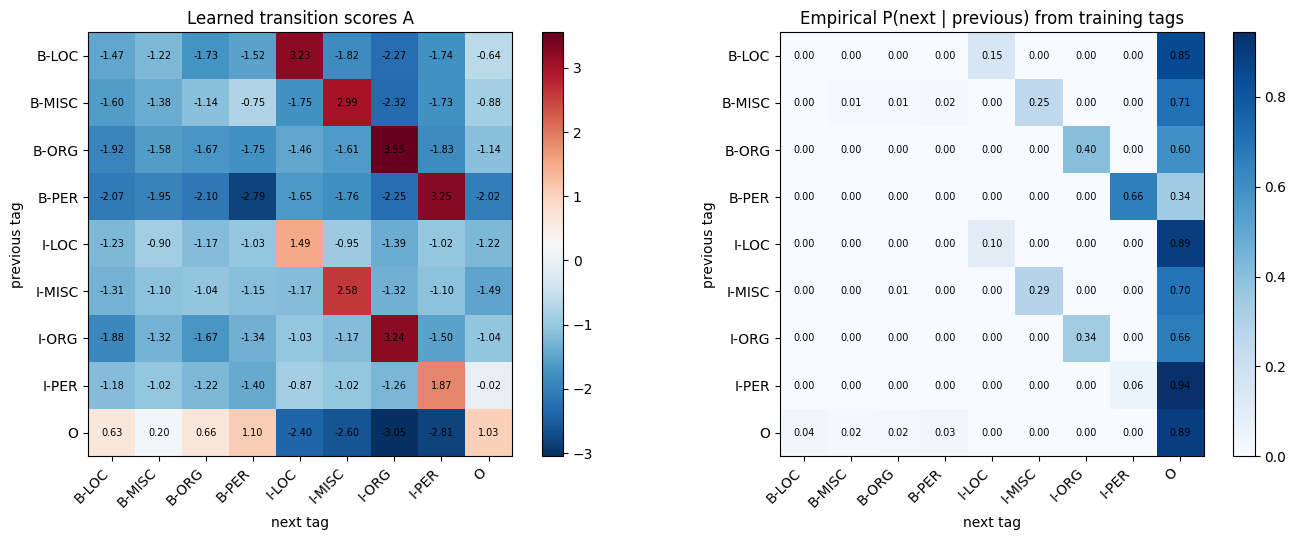

In [22]:
# Learned transition scores (rows: previous tag, columns: next tag)
learned = pd.DataFrame(crf_tagger.crf.transitions.detach().numpy(), index=TAGS, columns=TAGS)

# Empirical transitions: count consecutive tag pairs within each training sentence, then normalise rows
counts = pd.DataFrame(0, index=TAGS, columns=TAGS, dtype=float)
for _, tags in train:
    for prev, nxt in zip(tags[:-1], tags[1:]):
        counts.loc[prev, nxt] += 1
empirical = counts.div(counts.sum(axis=1), axis=0)          # P(next tag | previous tag)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, matrix, title in zip(axes, [learned, empirical], ["Learned transition scores A", "Empirical P(next | previous) from training tags"]):
    im = ax.imshow(matrix.values, cmap="RdBu_r" if title.startswith("Learned") else "Blues")
    ax.set_xticks(range(len(TAGS))); ax.set_xticklabels(TAGS, rotation=45, ha="right")
    ax.set_yticks(range(len(TAGS))); ax.set_yticklabels(TAGS)
    ax.set_xlabel("next tag"); ax.set_ylabel("previous tag"); ax.set_title(title)
    for r in range(len(TAGS)):
        for c in range(len(TAGS)):
            ax.text(c, r, f"{matrix.values[r, c]:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### Activity II

Read the two matrices side by side and write down your findings. In particular:

1. Which transitions get the most positive learned scores, and do they correspond to the largest empirical probabilities?
2. Which transitions are suppressed (strongly negative)? Are any of them impossible under the BIO scheme?
3. Where do the two matrices disagree, and what could explain the disagreement? (Hint: the learned scores share the job with the emissions, the empirical matrix does not.)

**Answer.**

1. The largest learned scores are on the "continue the entity" transitions, `B-X -> I-X` and `I-X -> I-X` for every type X, and on `O -> O`. These are also the rows with the highest empirical probabilities, so the two agree on what is common.
2. Every `-> I-X` transition from a tag that is not `B-X` or `I-X` is strongly negative (for example `O -> I-ORG`, `B-PER -> I-LOC`). Under the BIO scheme these transitions never occur, which is why the empirical matrix has zeros there; the CRF has learned the constraint from the data rather than being told it.
3. The two matrices disagree most in the `O` row and the `-> O` column. Empirically `O -> O` has probability 0.89 and `O -> B-X` only 0.02 to 0.04, yet the learned scores for `O -> O` and `O -> B-X` are all small and positive and close to one another (roughly 0.2 to 1.1). Likewise every `X -> O` transition is very common in the data (0.34 to 0.94) but gets a negative learned score. The reason is that transition scores are *added to* emission scores: the emissions already say clearly whether a word is an entity word, so the transitions do not need to repeat that information and instead spend their capacity on what the emissions cannot see, the B/I structure (continue the entity, never start an `I-` from nowhere). A transition the emissions already handle does not need a large score. This is also why comparing the learned matrix with the empirical one is a useful sanity check in Assessment 2: agreement on which transitions are favoured and suppressed is reassuring, and a disagreement usually points either at a training problem or at a transition the emissions already handle.